# **1. Mount Google Drive**

In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **2. Install Library**

In [48]:
!pip install opencv-python scikit-image

# **3. Import Library**

In [49]:
import cv2
import os
import numpy as np

from skimage.feature import graycomatrix, graycoprops
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# **4. Path Dataset**

In [50]:
# --- Helper cell to verify contents of 'Tugas Uts' ---
print("Listing contents of /content/drive/MyDrive/Tugas Uts/Classification:")
try:
    tugas_uts_path = '/content/drive/MyDrive/Tugas Uts/Classification'
    if os.path.exists(tugas_uts_path):
        for item in os.listdir(tugas_uts_path):
            print(f"- {item}")
    else:
        print(f"Error: '{tugas_uts_path}' does not exist. Please check your Google Drive mount or path.")
except Exception as e:
    print(f"An error occurred while listing contents of 'Tugas Uts': {e}")
print("\n--- End of 'Tugas Uts' path verification ---")

Listing contents of /content/drive/MyDrive/Tugas Uts/Classification:
- test
- training

--- End of 'Tugas Uts' path verification ---


# **5. Cek Folder**

In [51]:
# --- Helper cell to verify Google Drive path ---
print("Listing contents of /content/drive/MyDrive:")
try:
    # Check if MyDrive exists before trying to list its contents
    if os.path.exists('/content/drive/MyDrive'):
        for item in os.listdir('/content/drive/MyDrive'):
            print(f"- {item}")
    else:
        print("'/content/drive/MyDrive' does not exist. Google Drive might not be correctly mounted.")
        print("Please re-run the 'Mount Google Drive' cell (Cell CKdSblHPaYC_).")
except Exception as e:
    print(f"An error occurred while listing /content/drive/MyDrive: {e}")
print("\n--- End of Google Drive path verification ---")

Listing contents of /content/drive/MyDrive:
- Praktikum pcd 
- Praktikum Embeded
- berikan Rute Wiring ada gambar di atas ini.gsheet
- Tugas embeded mk
- itemreport2025_11_11_12_15_10_.pdf
- ellbru.pdf
- Tugas SPK MK
- Screenshot_20251209_141507_GoPay.jpg
- tugas embeded mk
- HELENA RAHATEN_2318123
- Colab Notebooks
- Tugas UTS Bussiness Intellegence
- Tugas Uts

--- End of Google Drive path verification ---


# **6. Distribusi jumlah data**

In [52]:
import os

folder = "/content/drive/MyDrive/Tugas Uts/Classification/training"

for label in os.listdir(folder):
    if label.lower() == "unknown":
        continue

    path = os.path.join(folder, label)

    if os.path.isdir(path):
        print(label, ":", len(os.listdir(path)))

bean_rust : 1750
als : 1750
healthy : 1600


# **6. Fungsi Ekstraksi Fitur**

In [53]:
def extract_features(image):
    image = cv2.resize(image, (128, 128))

    # ===== WARNA (HSV) =====
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0,1,2], None, [8,8,8],
                        [0,180,0,256,0,256])
    hist = cv2.normalize(hist, hist).flatten()

    # ===== TEKSTUR (GLCM) =====
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    glcm = graycomatrix(gray, distances=[1], angles=[0],
                        levels=256, symmetric=True, normed=True)

    contrast = graycoprops(glcm, 'contrast')[0][0]
    energy = graycoprops(glcm, 'energy')[0][0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0][0]
    correlation = graycoprops(glcm, 'correlation')[0][0]

    texture = [contrast, energy, homogeneity, correlation]

    return np.hstack([hist, texture])

# **7. Load Data**

In [54]:
import os

folder = "/content/drive/MyDrive/Tugas Uts/Classification/training" # Corrected capitalization

for item in os.listdir(folder):
    path = os.path.join(folder, item)
    print(item, "->", "Folder" if os.path.isdir(path) else "File")

bean_rust -> Folder
als -> Folder
healthy -> Folder


# **8.Ekstraksi fitur (HSV + GLCM)**

In [55]:
def extract_features(image):
    # --- HSV HISTOGRAM ---
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0,1,2], None, [8,8,8],
                        [0,180,0,256,0,256])
    hist = cv2.normalize(hist, hist).flatten()

    # --- GLCM (TEKSTUR) ---
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm, 'contrast').flatten()
    correlation = graycoprops(glcm, 'correlation').flatten()
    energy = graycoprops(glcm, 'energy').flatten()
    homogeneity = graycoprops(glcm, 'homogeneity').flatten()

    glcm_features = np.hstack([contrast, correlation, energy, homogeneity])

    features = np.hstack([hist, glcm_features])

    return features

In [56]:
import os
import cv2
import numpy as np

X_features = []
y_labels = []

dataset_list = [] # List to store (img_path, label) tuples

# 'folder' is defined in cell 2MpiH-jOvDVw, e.g., '/content/drive/MyDrive/Tugas Uts/Classification/training'
for label_name in os.listdir(folder):
    label_path = os.path.join(folder, label_name)
    if not os.path.isdir(label_path):
        continue # Skip if not a directory

    for file_name in os.listdir(label_path):
        if file_name.endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
            img_path = os.path.join(label_path, file_name)
            dataset_list.append((img_path, label_name))

# Now, iterate through the created dataset_list to extract features
for img_path, label in dataset_list:
    image = cv2.imread(img_path)
    if image is None:
        print(f"Warning: Could not load image from {img_path}. Skipping.")
        continue
    fitur = extract_features(image)
    X_features.append(fitur)
    y_labels.append(label)

# Convert to numpy arrays for sklearn and assign to 'data' and 'labels'
# to be consistent with subsequent cells like train_test_split
data = np.array(X_features)
labels = np.array(y_labels)

print(f"Successfully extracted features from {len(data)} images.")
print(f"Shape of data: {data.shape}")
print(f"Number of labels: {len(labels)}")

Successfully extracted features from 5100 images.
Shape of data: (5100, 528)
Number of labels: 5100


# **9. Split Data**

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

# **10. Training Random Forest**

In [58]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# **11. Confusion Matrix**

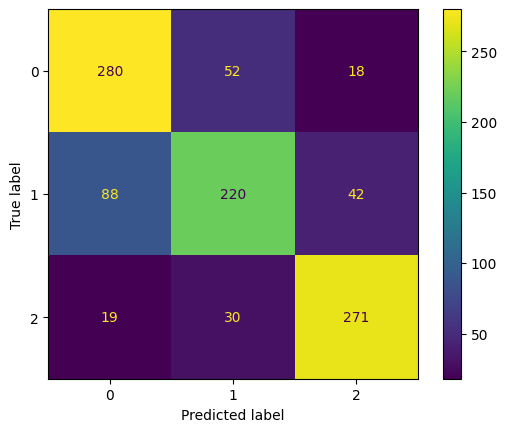

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# **11. Evaluasi Model**

In [60]:
y_pred = model.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Akurasi: 0.7558823529411764

Classification Report:

              precision    recall  f1-score   support

         als       0.72      0.80      0.76       350
   bean_rust       0.73      0.63      0.67       350
     healthy       0.82      0.85      0.83       320

    accuracy                           0.76      1020
   macro avg       0.76      0.76      0.76      1020
weighted avg       0.76      0.76      0.75      1020



# **12. Gabungkan hasil ke dalam tabel**

In [61]:
import pandas as pd

# buat dataframe
df = pd.DataFrame(X_test)

df['Actual_Label'] = y_test
df['Predicted_Label'] = y_pred

df.head()

,0,1,2,3,4,5,6,7,8,9,...,520,521,522,523,524,525,526,527,Actual_Label,Predicted_Label
0,0.001862,0.024675,0.038549,0.045905,0.027375,0.004469,0.000186,0.000093,0.001583,0.022626,...,0.017464,0.015501,0.017161,0.015227,0.158893,0.125509,0.152712,0.120839,bean_rust,bean_rust
1,0.000133,0.000799,0.000333,0.000866,0.000932,0.002864,0.008592,0.044225,0.000133,0.002598,...,0.024898,0.020115,0.021853,0.019954,0.259496,0.180838,0.214810,0.180599,healthy,healthy
2,0.000000,0.000468,0.003466,0.000656,0.000749,0.001030,0.002904,0.003560,0.000000,0.000562,...,0.018381,0.016939,0.020008,0.016741,0.165580,0.139429,0.191693,0.136043,als,als
3,0.000673,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000481,0.000000,...,0.014354,0.012342,0.013658,0.012365,0.152933,0.111669,0.139069,0.111938,bean_rust,bean_rust
4,0.000000,0.000230,0.000000,0.000574,0.000689,0.001837,0.001722,0.000115,0.000000,0.005281,...,0.012349,0.010725,0.011568,0.010746,0.105816,0.075267,0.090936,0.077053,healthy,healthy


# **13. Simpan ke CSV**

In [62]:
import pandas as pd
import os

# ambil fitur hasil ekstraksi
df = pd.DataFrame(X_test)

# kasih nama kolom fitur
df.columns = [f'fitur_{i}' for i in range(len(df.columns))]

# tambah label
df['Actual'] = y_test.values if hasattr(y_test, "values") else y_test
df['Predicted'] = y_pred

# =========================
# RAPIKAN URUTAN KOLOM
# =========================
feature_cols = [col for col in df.columns if 'fitur_' in col]
df = df[feature_cols + ['Actual', 'Predicted']]

# =========================
# SIMPAN KE GOOGLE DRIVE
# =========================
path_folder = "/content/drive/MyDrive/Tugas Uts"
os.makedirs(path_folder, exist_ok=True)

csv_path = path_folder + "/hasil_ekstraksi_hsv_glcm.csv"
df.to_csv(csv_path, index=False)

print("File berhasil disimpan di:", csv_path)

File berhasil disimpan di: /content/drive/MyDrive/Tugas Uts/hasil_ekstraksi_hsv_glcm.csv
